In [5]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [1]:
import pymc as pm
import arviz as az

print(f"PyMC: {pm.__version__}")
print(f"ArviZ: {az.__version__}")

PyMC: 6.3.2
ArviZ: 1.3.0


In [6]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.pyplot import imshow
import seaborn as sns
#import pymc as pm

from datetime import datetime
from tqdm.notebook import tqdm

In [7]:
surface_df_path = "/Users/giancarlomanzi/Documents/Box Sync BackUp PC Lavoro 24062015/documenti/Didattica/Tesisti 2024/Kurch/Thesis material (useful for JMI paper)/plant-growth-prediction/analysis/data/clean_daylight_surface_ts.csv"

In [8]:
raw_df = pd.read_csv(surface_df_path)
raw_df["date_time"] = pd.to_datetime(raw_df["date_time"])
raw_df["plant_num"] = raw_df["plant_num"].astype(str)
raw_df["date"] = raw_df["date_time"].dt.normalize()
raw_df

,img_name,plant_num,date_time,surface,date
0,lettuce1_2024-06-15_07.jpg,1,2024-06-15 07:00:00,0.000000,2024-06-15
1,lettuce1_2024-06-15_08.jpg,1,2024-06-15 08:00:00,0.000000,2024-06-15
2,lettuce1_2024-06-15_09.jpg,1,2024-06-15 09:00:00,0.000000,2024-06-15
3,lettuce1_2024-06-15_10.jpg,1,2024-06-15 10:00:00,0.000000,2024-06-15
4,lettuce1_2024-06-15_11.jpg,1,2024-06-15 11:00:00,0.000000,2024-06-15
...,...,...,...,...,...
5499,lettuce8_2024-07-26_12.jpg,8,2024-07-26 12:00:00,281.915085,2024-07-26
5500,lettuce8_2024-07-26_13.jpg,8,2024-07-26 13:00:00,281.886747,2024-07-26
5501,lettuce8_2024-07-26_14.jpg,8,2024-07-26 14:00:00,280.357834,2024-07-26
5502,lettuce8_2024-07-26_15.jpg,8,2024-07-26 15:00:00,281.198534,2024-07-26


In [9]:
def plot_ts(x, y, df, hue=None):
    fig = plt.figure(figsize=(12, 6))

    if hue:
        sns.lineplot(x=x, y=y, data=df, hue=hue)
    else:
        sns.lineplot(x=x, y=y, data=df)
    plt.xlabel('Date Time')
    plt.ylabel('Surface cm2')
    plt.title('Plant surface cm2 over time')
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.tight_layout()

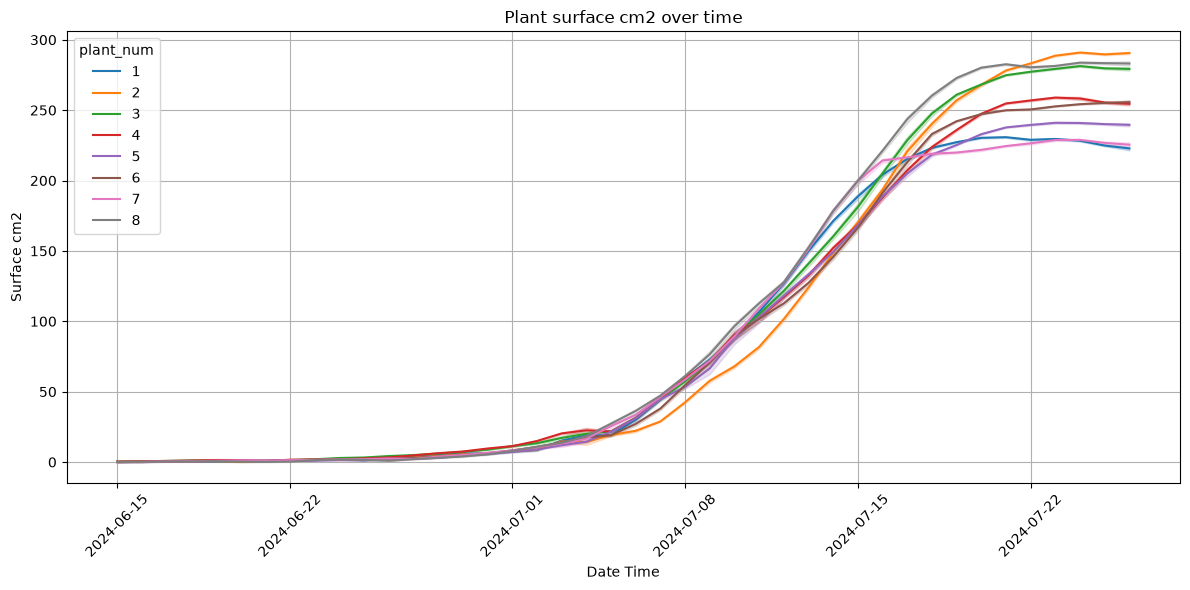

In [10]:
plot_ts(x="date", y="surface", df=raw_df, hue="plant_num")

In [11]:
df = raw_df.groupby(["plant_num", "date"])["surface"].mean().reset_index()
df["days_from_start"] = (df["date"] - df.groupby('plant_num')["date"].transform('min')).dt.days
mean_df = df.groupby("days_from_start")["surface"].mean().sort_index().reset_index()
df.head()

,plant_num,date,surface,days_from_start
0,1,2024-06-15,0.000000,0
1,1,2024-06-16,0.158717,1
2,1,2024-06-17,0.340680,2
3,1,2024-06-18,0.523646,3
4,1,2024-06-19,0.351673,4


In [13]:
train_plants = ["1", "2", "3", "4", "5", "6"]
test_plants = ["7", "8"]

train_df = df[df["plant_num"].isin(train_plants)]
test_df7 = df[df["plant_num"] == test_plants[0]]
test_df8 = df[df["plant_num"] == test_plants[1]]

### PyMC 

In [16]:
# Let's define the sigmoid function
def sigmoid(t, A, k, t0):
    return A / (1 + np.exp(-k * (t - t0)))

# PyMC Model
def train_model(df, A_mu=250, A_sigma=50, k_mu=1.0, k_sigma=0.5, t0_mu=20, t0_sigma=5):
    with pm.Model() as model:
        # Priors for parameters A, k, t0
        A = pm.Normal('A', mu=A_mu, sigma=A_sigma)  # Prior for max surface area
        k = pm.Normal('k', mu=k_mu, sigma=k_sigma) # Prior for growth rate
        t0 = pm.Normal('t0', mu=t0_mu, sigma=t0_sigma)  # Prior for inflection point (mid of growth)
    
        # Expected sigmoid growth for each day
        day_data = df["days_from_start"].values
        growth_curve = sigmoid(day_data, A, k, t0)
    
        # Likelihood (observed data)
        surface_data = df["surface"].values
        sigma = pm.HalfNormal('sigma', sigma=10)  # Error term
        likelihood = pm.Normal('surface', mu=growth_curve, sigma=sigma, observed=surface_data)
    
        # Inference
        trace = pm.sample(1000, tune=1000, return_inferencedata=True)
        return trace

In [25]:
#NUOVA FUNZIONE AL POSTO DI QUELLA NEL CHUNK PRECEDENTE PERCHé USO PyMC5+
import numpy as np
import pymc as pm
import arviz as az

def sigmoid(t, A, k, t0):
    return A / (1 + np.exp(-k * (t - t0)))

# PyMC Model
def train_model(df, A_mu=250, A_sigma=50, k_mu=1.0, k_sigma=0.5, t0_mu=20, t0_sigma=5):
    with pm.Model() as model:
        A = pm.Normal('A', mu=A_mu, sigma=A_sigma)
        k = pm.Normal('k', mu=k_mu, sigma=k_sigma)
        t0 = pm.Normal('t0', mu=t0_mu, sigma=t0_sigma)
    
        day_data = df["days_from_start"].values
        growth_curve = sigmoid(day_data, A, k, t0)
    
        surface_data = df["surface"].values
        sigma = pm.HalfNormal('sigma', sigma=10)
        likelihood = pm.Normal('surface', mu=growth_curve, sigma=sigma, observed=surface_data)
    
        idata = pm.sample(1000, tune=1000)
    
    return idata

# Uso
idata = train_model(train_df)

# Visualizza il posterior (senza prior)
az.plot_trace(idata)
plt.show()

# O il forest plot (più elegante)
az.plot_forest(idata)
plt.show()

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [A, k, t0, sigma]


Output()

/opt/miniconda3/lib/python3.14/site-packages/pymc/step_methods/hmc/quadpotential.py:321: RuntimeWarning: overflow encountered in dot
  return 0.5 * np.dot(x, v_out)
/opt/miniconda3/lib/python3.14/site-packages/pymc/step_methods/hmc/quadpotential.py:321: RuntimeWarning: overflow encountered in dot
  return 0.5 * np.dot(x, v_out)


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [A, k, t0, sigma]


Output()

/opt/miniconda3/lib/python3.14/site-packages/pymc/step_methods/hmc/quadpotential.py:321: RuntimeWarning: overflow encountered in dot
  return 0.5 * np.dot(x, v_out)
/opt/miniconda3/lib/python3.14/site-packages/pymc/step_methods/hmc/quadpotential.py:321: RuntimeWarning: overflow encountered in dot
  return 0.5 * np.dot(x, v_out)


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.
Sampling: [surface]


Output()


CALIBRATION ANALYSIS - 95% Predictive Intervals
Nominal Coverage:     95.0%
Empirical Coverage:   90.9%
Observations Covered: 229/252
Mean Interval Width:  39.87 cm²
Std Interval Width:   0.61 cm²

Table: Calibration of Predictive Intervals
Credible Interval Level Nominal Coverage Empirical Coverage Observations Covered Mean Interval Width (cm²) Std Width (cm²)
                    95%            95.0%              90.9%              229/252                     39.87            0.61


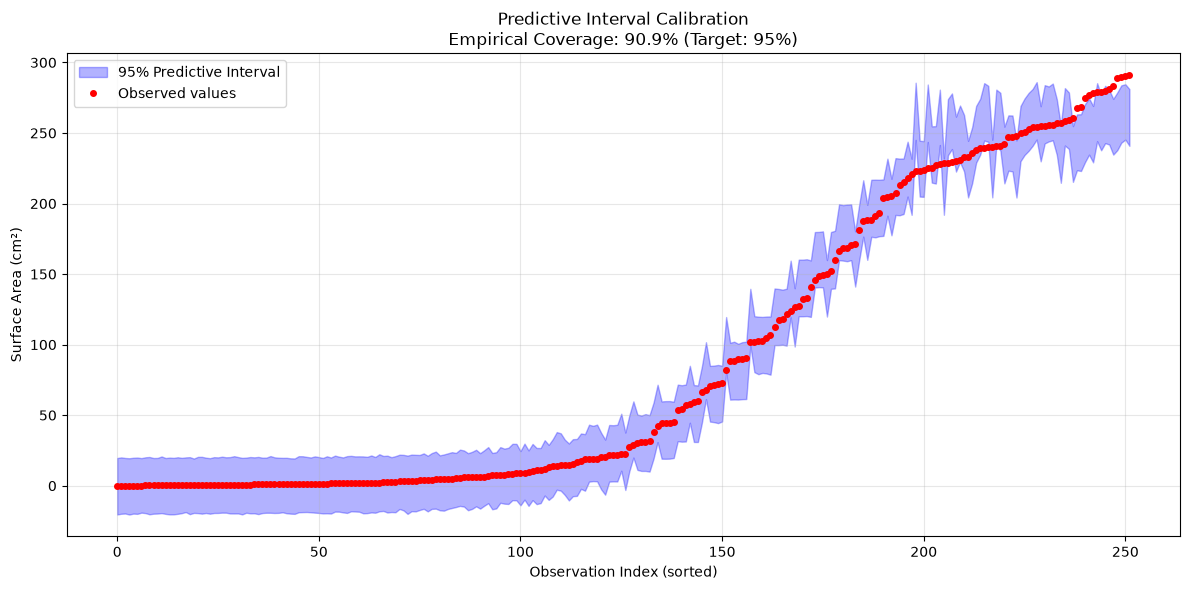

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import arviz as az

def generate_posterior_predictive(model, idata, df_test):
    """
    Genera posterior predictive samples per dati di test
    """
    with model:
        # Sample posterior predictive
        pm.sample_posterior_predictive(idata, extend_inferencedata=True)
    
    return idata

def calculate_coverage(df_test, idata, hdi_prob=0.95):
    """
    Calcola coverage, width, e metriche di calibration
    """
    # Estrai posterior predictive
    ppc_samples = idata.posterior_predictive['surface'].values  # shape: (chains, draws, obs)
    
    # Flatten chains e draws
    ppc_flat = ppc_samples.reshape(-1, ppc_samples.shape[-1])  # shape: (total_samples, obs)
    
    # Calcola HDI per ogni osservazione
    hdi_lower = np.percentile(ppc_flat, (1 - hdi_prob) / 2 * 100, axis=0)
    hdi_upper = np.percentile(ppc_flat, (1 + hdi_prob) / 2 * 100, axis=0)
    
    # Dati osservati
    observed = df_test["surface"].values
    
    # Coverage: quanti punti cadono dentro?
    coverage_mask = (hdi_lower <= observed) & (observed <= hdi_upper)
    empirical_coverage = coverage_mask.mean() * 100
    
    # Width: larghezza media
    widths = hdi_upper - hdi_lower
    mean_width = widths.mean()
    std_width = widths.std()
    
    # Numero di punti
    n_covered = coverage_mask.sum()
    n_total = len(observed)
    
    return {
        'empirical_coverage': empirical_coverage,
        'nominal_coverage': hdi_prob * 100,
        'n_covered': int(n_covered),
        'n_total': n_total,
        'mean_width': mean_width,
        'std_width': std_width,
        'hdi_lower': hdi_lower,
        'hdi_upper': hdi_upper,
        'coverage_mask': coverage_mask
    }

def plot_calibration(df_test, idata, calib_results):
    """Plot calibration visuale"""
    observed = df_test["surface"].values
    lower = calib_results['hdi_lower']
    upper = calib_results['hdi_upper']
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Ordina per observed per visualizzazione migliore
    idx = np.argsort(observed)
    obs_sorted = observed[idx]
    lower_sorted = lower[idx]
    upper_sorted = upper[idx]
    x = np.arange(len(obs_sorted))
    
    # Plot intervals
    ax.fill_between(x, lower_sorted, upper_sorted, alpha=0.3, label='95% Predictive Interval', color='blue')
    ax.plot(x, obs_sorted, 'ro', markersize=4, label='Observed values')
    
    ax.set_xlabel('Observation Index (sorted)')
    ax.set_ylabel('Surface Area (cm²)')
    ax.set_title(f'Predictive Interval Calibration\nEmpirical Coverage: {calib_results["empirical_coverage"]:.1f}% (Target: 95%)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    return fig

# UTILIZZO:
# =========

# 1. Allena il modello
idata = train_model(train_df)

# 2. Genera posterior predictive per il test set (o train set se non hai test)
with pm.Model() as model:
    A = pm.Normal('A', mu=250, sigma=50)
    k = pm.Normal('k', mu=1.0, sigma=0.5)
    t0 = pm.Normal('t0', mu=20, sigma=5)
    
    day_data = train_df["days_from_start"].values
    growth_curve = sigmoid(day_data, A, k, t0)
    
    surface_data = train_df["surface"].values
    sigma = pm.HalfNormal('sigma', sigma=10)
    likelihood = pm.Normal('surface', mu=growth_curve, sigma=sigma, observed=surface_data)
    
    pm.sample_posterior_predictive(idata, extend_inferencedata=True)

# 3. Calcola coverage
calib_results = calculate_coverage(train_df, idata, hdi_prob=0.95)

# 4. Stampa risultati
print("\n" + "="*60)
print("CALIBRATION ANALYSIS - 95% Predictive Intervals")
print("="*60)
print(f"Nominal Coverage:     95.0%")
print(f"Empirical Coverage:   {calib_results['empirical_coverage']:.1f}%")
print(f"Observations Covered: {calib_results['n_covered']}/{calib_results['n_total']}")
print(f"Mean Interval Width:  {calib_results['mean_width']:.2f} cm²")
print(f"Std Interval Width:   {calib_results['std_width']:.2f} cm²")
print("="*60 + "\n")

# 5. Crea tabella
calib_table = pd.DataFrame({
    'Credible Interval Level': ['95%'],
    'Nominal Coverage': ['95.0%'],
    'Empirical Coverage': [f"{calib_results['empirical_coverage']:.1f}%"],
    'Observations Covered': [f"{calib_results['n_covered']}/{calib_results['n_total']}"],
    'Mean Interval Width (cm²)': [f"{calib_results['mean_width']:.2f}"],
    'Std Width (cm²)': [f"{calib_results['std_width']:.2f}"]
})

print("Table: Calibration of Predictive Intervals")
print(calib_table.to_string(index=False))

# 6. Plot calibration
fig = plot_calibration(train_df, idata, calib_results)
plt.savefig('calibration_plot.png', dpi=300, bbox_inches='tight')
plt.show()

In [19]:
import arviz as az
print(dir(az))

['AzStatsDaAccessor', 'AzStatsDsAccessor', 'AzStatsDtAccessor', 'ELPDData', 'ELPDDataLFO', 'ELPDDataLOO', 'ELPDDataLOOKFold', 'ELPDDataLOOSubsample', 'MCMCAdapter', 'MigrationWarning', 'NumPyroInferenceAdapter', 'PlotCollection', 'PlotMatrix', 'SVIAdapter', 'SamplingWrapper', '_MIGRATION_GUIDE_URL', '__builtins__', '__cached__', '__doc__', '__file__', '__getattr__', '__loader__', '__name__', '__package__', '__path__', '__spec__', '__version__', '_log', 'accessors', 'add_bands', 'add_lines', 'base', 'bayes_factor', 'bayesian_r2', 'bfmi', 'ci_in_rope', 'citations', 'clear_data_home', 'combine_plots', 'compare', 'convert_to_dataset', 'convert_to_datatree', 'dataset_to_dataarray', 'dataset_to_dataframe', 'diagnose', 'dict_to_dataset', 'ecdf', 'ess', 'eti', 'explode_dataset_dims', 'extract', 'from_cmdstanpy', 'from_dict', 'from_emcee', 'from_netcdf', 'from_numpyro', 'from_numpyro_svi', 'from_zarr', 'generate_dims_coords', 'generate_survival_curves', 'get_data_home', 'get_function', 'get_log

In [17]:
#VECCHIA
import arviz as az
idata = train_model(train_df)  # ora restituisce idata, non trace
az.plot_posterior(idata)
plt.show()

#trace = train_model(train_df)
#pm.plot_posterior(trace)
#plt.show()

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [A, k, t0, sigma]


Output()

/opt/miniconda3/lib/python3.14/site-packages/pymc/step_methods/hmc/quadpotential.py:321: RuntimeWarning: overflow encountered in dot
  return 0.5 * np.dot(x, v_out)
/opt/miniconda3/lib/python3.14/site-packages/pymc/step_methods/hmc/quadpotential.py:321: RuntimeWarning: overflow encountered in dot
  return 0.5 * np.dot(x, v_out)


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.


AttributeError: module 'arviz' has no attribute 'plot_posterior'

In [49]:
def plot_plant_growth(trace, x_line=None, y_line=None, label_line=None,
                      x_line2=None, y_line2=None, label_line2=None,
                      x_scatter=None, y_scatter=None, label_scatter=None):
    days = np.arange(0, 41)
    
    # Extract posterior samples
    A_samples = trace.posterior['A'].values.flatten()  # Flatten the multidimensional arrays
    k_samples = trace.posterior['k'].values.flatten()
    t0_samples = trace.posterior['t0'].values.flatten()
    
    # Initialize an array to store growth curves
    growth_curves = np.zeros((len(A_samples), len(days)))
    
    # Compute the growth curve for each sample
    for i in range(len(A_samples)):
        growth_curves[i, :] = sigmoid(days, A_samples[i], k_samples[i], t0_samples[i])
    
    # Compute the mean, 2.5th, and 97.5th percentiles for each day (to get 95% CI)
    mean_growth = np.mean(growth_curves, axis=0)
    ci_lower = np.percentile(growth_curves, 2.5, axis=0)
    ci_upper = np.percentile(growth_curves, 97.5, axis=0)
    
    # Plot the mean and the 95% confidence interval
    plt.figure(figsize=(10, 6))
    plt.plot(days, mean_growth, label='Mean Growth Curve', color='blue')
    plt.fill_between(days, ci_lower, ci_upper, color='blue', alpha=0.3, label='95% Confidence Interval')
    if not x_line is None and not y_line is None:
        plt.plot(x_line, y_line, label=label_line, color="red")
    if not x_scatter is None and not y_scatter is None:
        plt.scatter(x=x_scatter, y=y_scatter, label=label_scatter, color="red")
    if not x_line2 is None and not y_line2 is None:
        plt.plot(x_line2, y_line2, label=label_line2, color="green")
    plt.xlabel('Days from start')
    plt.ylabel('Surface Area (cm²)')
    plt.title('Predicted Plant Growth with 95% Confidence Interval')
    plt.legend()
    plt.grid(True)
    plt.show()

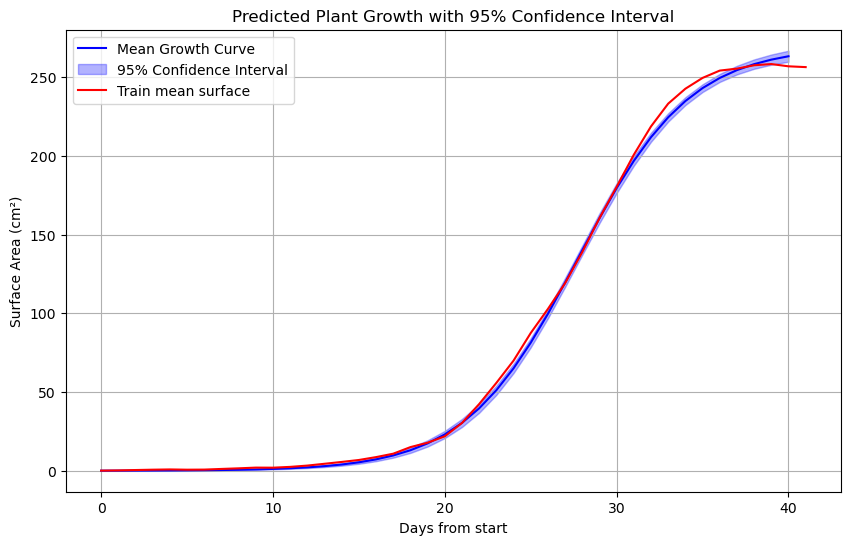

In [52]:
plot_plant_growth(trace, x_line=mean_df["days_from_start"], y_line=mean_df["surface"], label_line="Train mean surface")

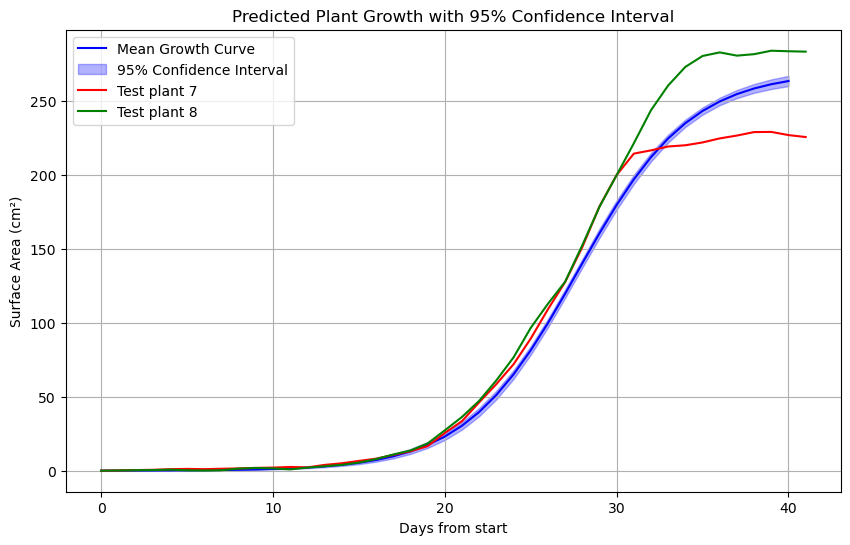

In [51]:
plot_plant_growth(trace, x_line=test_df8["days_from_start"], y_line=test_df8["surface"], label_line="Test plant 7",
                 x_line2=test_df8["days_from_start"], y_line2=test_df8["surface"], label_line2="Test plant 8")

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [A, k, t0, sigma]


Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.


Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.


...

WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.


Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 19 seconds.
There were 185 divergences after tuning. Increase `target_accept` or reparameterize.
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


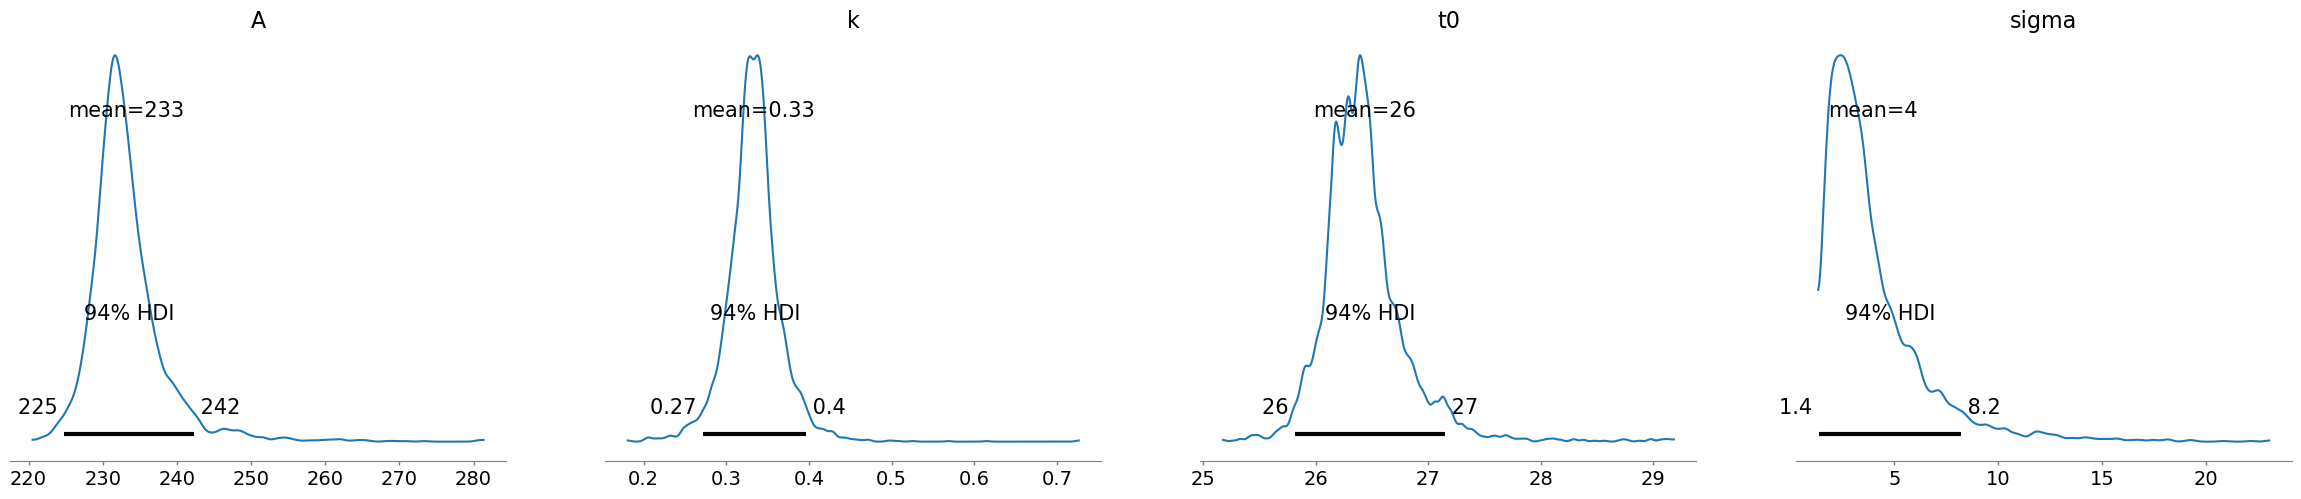

In [56]:
test_days = [10, 15, 20, 25, 35, 40]
test_points = test_df7[test_df7["days_from_start"].isin(test_days)]

# Use posterior distributions to create prior for test adjustments
# For adjusting based on new test points
trace_adj = train_model(test_points, 
                        A_mu=trace.posterior['A'].mean().values, A_sigma=20,
                        k_mu=trace.posterior['k'].mean().values, k_sigma=0.3,
                        t0_mu=trace.posterior['t0'].mean().values, t0_sigma=3)

# Plot adjusted growth curve
pm.plot_posterior(trace_adj)
plt.show()

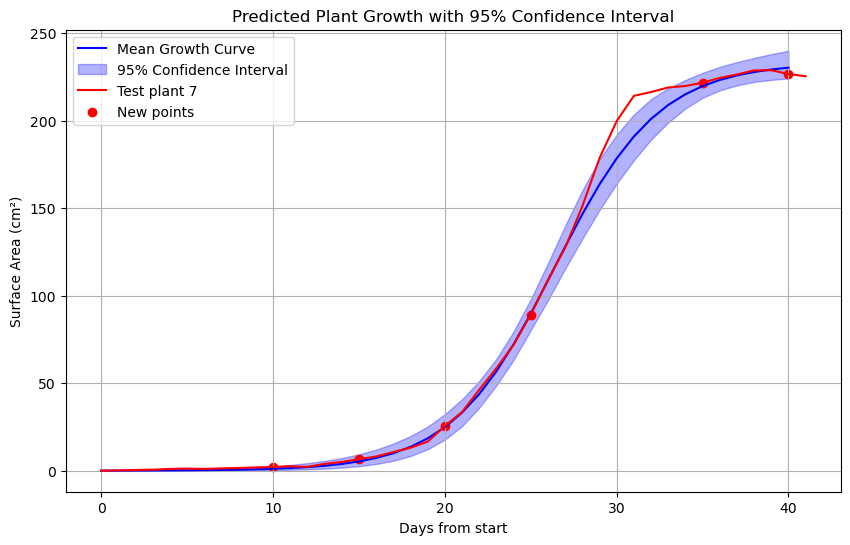

In [59]:
plot_plant_growth(trace_adj, x_line=test_df7["days_from_start"], y_line=test_df7["surface"], label_line="Test plant 7",
                  x_scatter=test_points["days_from_start"], y_scatter=test_points["surface"], label_scatter="New points")

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [A, k, t0, sigma]


Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.


Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.


...

WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.


Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 23 seconds.
There were 2 divergences after tuning. Increase `target_accept` or reparameterize.


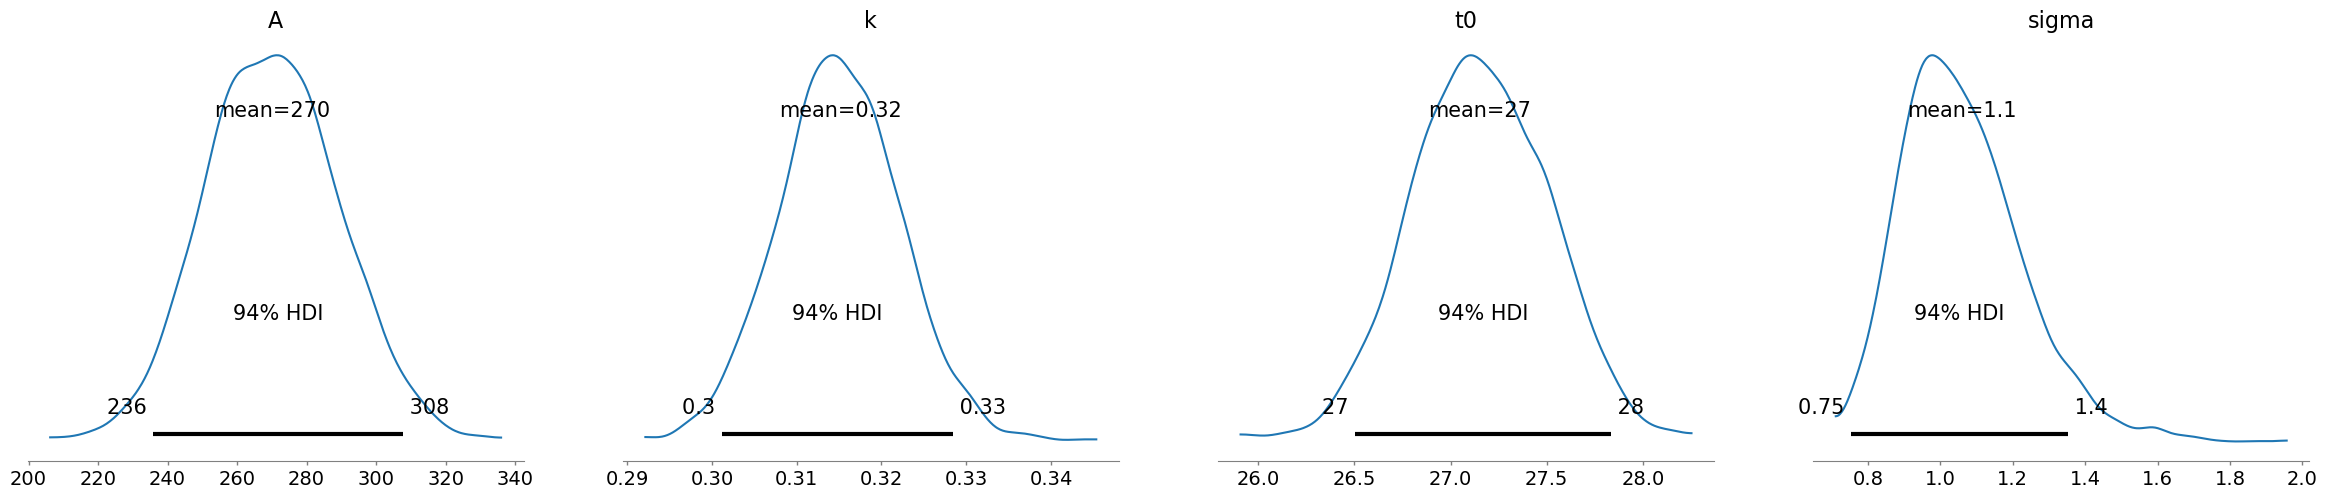

In [60]:
test_days = list(range(25))
test_points = test_df7[test_df7["days_from_start"].isin(test_days)]

# Use posterior distributions to create prior for test adjustments
# For adjusting based on new test points
trace_adj = train_model(test_points, 
                        A_mu=trace.posterior['A'].mean().values, A_sigma=20,
                        k_mu=trace.posterior['k'].mean().values, k_sigma=0.3,
                        t0_mu=trace.posterior['t0'].mean().values, t0_sigma=3)

# Plot adjusted growth curve
pm.plot_posterior(trace_adj)
plt.show()

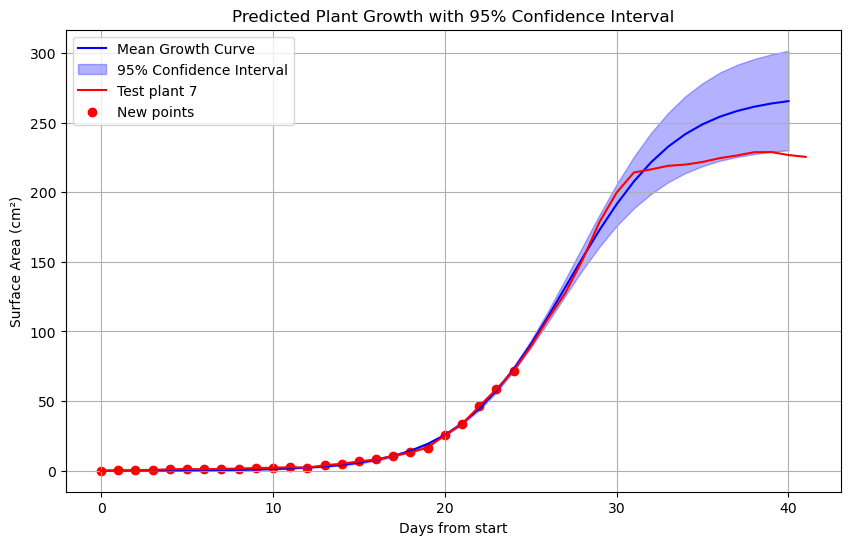

In [61]:
plot_plant_growth(trace_adj, x_line=test_df7["days_from_start"], y_line=test_df7["surface"], label_line="Test plant 7",
                  x_scatter=test_points["days_from_start"], y_scatter=test_points["surface"], label_scatter="New points")

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [A, k, t0, sigma]


Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.


Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.


...

WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.


Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 20 seconds.
There were 232 divergences after tuning. Increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


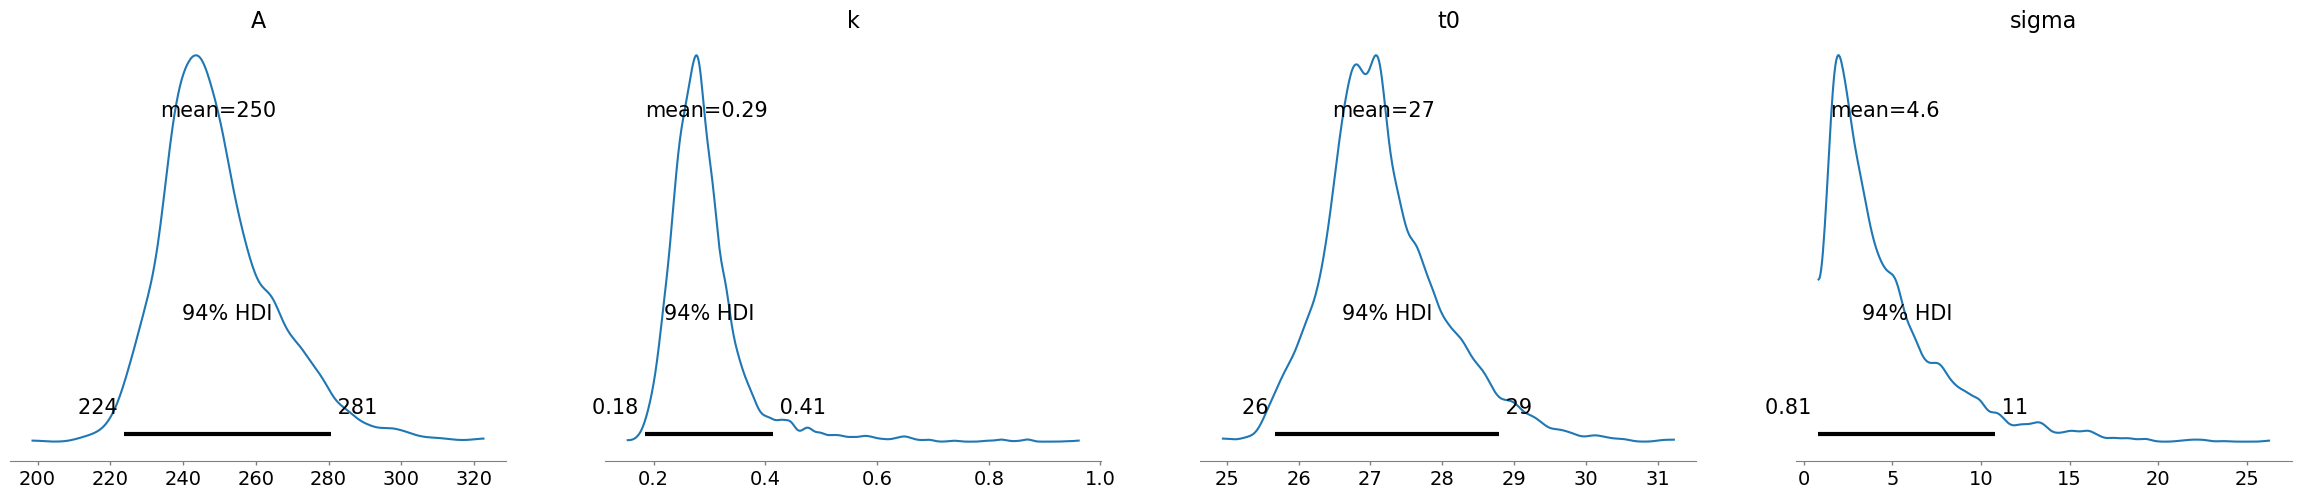

In [64]:
test_days = [5, 15, 25, 35]
test_points = test_df7[test_df7["days_from_start"].isin(test_days)]

# Use posterior distributions to create prior for test adjustments
# For adjusting based on new test points
trace_adj = train_model(test_points, 
                        A_mu=trace.posterior['A'].mean().values, A_sigma=20,
                        k_mu=trace.posterior['k'].mean().values, k_sigma=0.3,
                        t0_mu=trace.posterior['t0'].mean().values, t0_sigma=3)

# Plot adjusted growth curve
pm.plot_posterior(trace_adj)
plt.show()

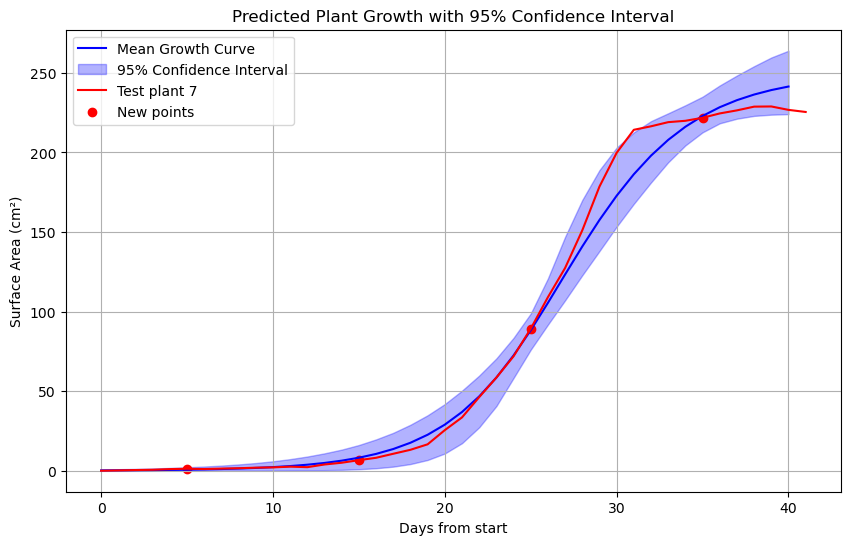

In [65]:
plot_plant_growth(trace_adj, x_line=test_df7["days_from_start"], y_line=test_df7["surface"], label_line="Test plant 7",
                  x_scatter=test_points["days_from_start"], y_scatter=test_points["surface"], label_scatter="New points")